# Task
Analyze student learning patterns using K-means and Hierarchical clustering on the dataset at "/content/student_education_dataset.csv" to recommend resources.

## Load the data

### Subtask:
Load the data from "/content/student_education_dataset.csv" into a pandas DataFrame.


**Reasoning**:
Load the data into a pandas DataFrame and display the head and info to understand the data.



In [7]:
import pandas as pd

df = pd.read_csv('/content/student_education_dataset.csv')
display(df.head())
display(df.info())

,StudentID,AcademicScore,CourseParticipation,AttendanceRate,PhysicalActivity,EmotionEngagement,LearningStyle,DeviceUsage,FeedbackScore,StudentPerformance
0,1,88,32,0.562110,4697,0.327045,Kinesthetic,29,2.800945,2
1,2,78,21,0.948111,340,0.890057,Auditory,25,2.018995,1
2,3,64,20,0.797388,3828,0.084301,Visual,1,2.407539,1
3,4,92,5,0.808302,1968,0.807189,Kinesthetic,25,3.822461,2
4,5,57,5,0.806472,703,0.861320,Auditory,3,3.086204,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StudentID            1000 non-null   int64  
 1   AcademicScore        1000 non-null   int64  
 2   CourseParticipation  1000 non-null   int64  
 3   AttendanceRate       1000 non-null   float64
 4   PhysicalActivity     1000 non-null   int64  
 5   EmotionEngagement    1000 non-null   float64
 6   LearningStyle        1000 non-null   object 
 7   DeviceUsage          1000 non-null   int64  
 8   FeedbackScore        1000 non-null   float64
 9   StudentPerformance   1000 non-null   int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 78.3+ KB


None

## Data preprocessing

### Subtask:
Prepare the data for clustering by handling categorical variables and scaling numerical features.


**Reasoning**:
Identify categorical columns, apply one-hot encoding, identify numerical columns, scale numerical features, and concatenate them into a single DataFrame for clustering.



In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=np.number).columns.drop('StudentID')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

df_processed = preprocessor.fit_transform(df)

## Determine optimal number of clusters

### Subtask:
Use methods like the elbow method or silhouette score to find the optimal number of clusters for K-means.


**Reasoning**:
Implement the elbow method and silhouette score analysis to find the optimal number of clusters for K-means and visualize the results.



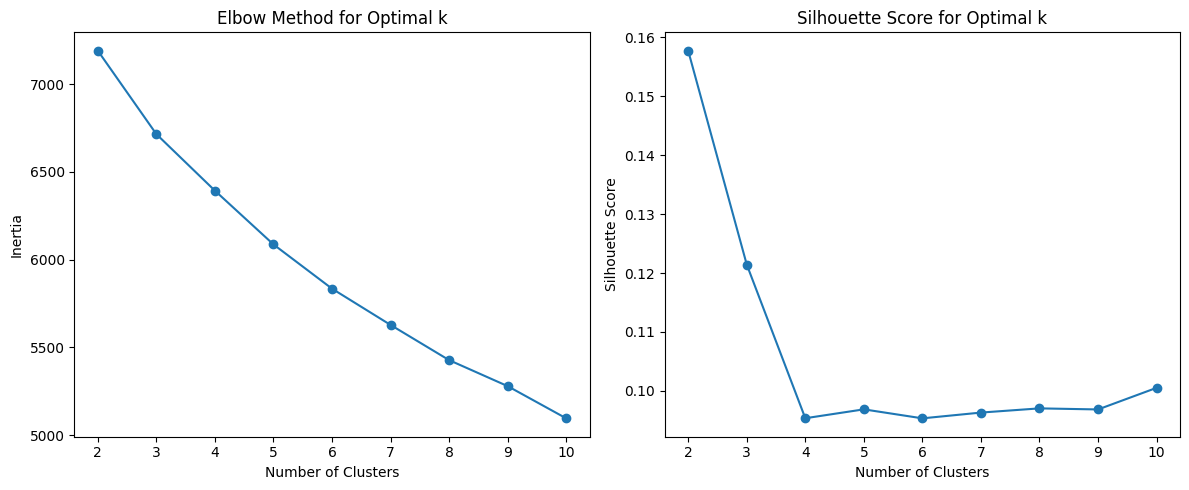

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(df_processed)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_processed, kmeans.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')

plt.tight_layout()
plt.show()

## Apply k-means clustering

### Subtask:
Train a K-means model with the optimal number of clusters and assign cluster labels to each student.


**Reasoning**:
Instantiate and fit the KMeans model with the determined optimal number of clusters, then add the cluster labels to the original DataFrame.



In [10]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(df_processed)
df['KMeans_Cluster'] = kmeans.labels_
display(df.head())

,StudentID,AcademicScore,CourseParticipation,AttendanceRate,PhysicalActivity,EmotionEngagement,LearningStyle,DeviceUsage,FeedbackScore,StudentPerformance,KMeans_Cluster
0,1,88,32,0.562110,4697,0.327045,Kinesthetic,29,2.800945,2,8
1,2,78,21,0.948111,340,0.890057,Auditory,25,2.018995,1,1
2,3,64,20,0.797388,3828,0.084301,Visual,1,2.407539,1,7
3,4,92,5,0.808302,1968,0.807189,Kinesthetic,25,3.822461,2,5
4,5,57,5,0.806472,703,0.861320,Auditory,3,3.086204,0,0


## Apply hierarchical clustering

### Subtask:
Train a Hierarchical clustering model with the optimal number of clusters and assign cluster labels to each student.


**Reasoning**:
Instantiate and fit the AgglomerativeClustering model, then add the cluster labels to the dataframe and display the head.



In [11]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(df_processed)

df['Hierarchical_Cluster'] = hierarchical_labels
display(df.head())

,StudentID,AcademicScore,CourseParticipation,AttendanceRate,PhysicalActivity,EmotionEngagement,LearningStyle,DeviceUsage,FeedbackScore,StudentPerformance,KMeans_Cluster,Hierarchical_Cluster
0,1,88,32,0.562110,4697,0.327045,Kinesthetic,29,2.800945,2,8,3
1,2,78,21,0.948111,340,0.890057,Auditory,25,2.018995,1,1,2
2,3,64,20,0.797388,3828,0.084301,Visual,1,2.407539,1,7,3
3,4,92,5,0.808302,1968,0.807189,Kinesthetic,25,3.822461,2,5,2
4,5,57,5,0.806472,703,0.861320,Auditory,3,3.086204,0,0,5


## Analyze clusters

### Subtask:
Examine the characteristics of each cluster to understand the different learning patterns.


**Reasoning**:
Group the DataFrame by the 'KMeans_Cluster' and 'Hierarchical_Cluster' columns and calculate the mean of each numerical feature for each cluster to understand the characteristics of each cluster.



In [12]:
kmeans_cluster_means = df.groupby('KMeans_Cluster')[numerical_features].mean()
display(kmeans_cluster_means)

hierarchical_cluster_means = df.groupby('Hierarchical_Cluster')[numerical_features].mean()
display(hierarchical_cluster_means)

,AcademicScore,CourseParticipation,AttendanceRate,PhysicalActivity,EmotionEngagement,DeviceUsage,FeedbackScore,StudentPerformance
KMeans_Cluster,,,,,,,,
0,58.373626,22.395604,0.720354,926.043956,0.419753,9.450549,3.492078,0.340659
1,65.859813,24.046729,0.681968,2429.420561,0.685986,23.336449,2.198577,0.738318
2,89.142857,15.616071,0.711580,3351.392857,0.768708,12.535714,2.805827,1.964286
3,62.956989,37.752688,0.728329,3518.516129,0.431910,13.817204,4.030640,0.591398
4,86.309091,28.390909,0.622425,1896.172727,0.282539,10.718182,2.170394,1.800000
5,83.393258,9.033708,0.850594,1761.033708,0.317530,18.247191,3.312185,1.640449
6,82.653061,35.642857,0.799103,1421.214286,0.678993,17.214286,3.919226,1.663265
7,64.867257,26.292035,0.793259,3063.230088,0.633337,5.893805,1.975675,0.716814
8,87.860000,34.900000,0.817787,3747.210000,0.358646,18.550000,2.560098,1.880000


,AcademicScore,CourseParticipation,AttendanceRate,PhysicalActivity,EmotionEngagement,DeviceUsage,FeedbackScore,StudentPerformance
Hierarchical_Cluster,,,,,,,,
0,67.011765,18.641176,0.751652,2891.776471,0.321749,19.029412,3.437291,0.794118
1,89.212121,26.232323,0.628422,1439.979798,0.418898,14.090909,2.641412,1.959596
2,81.000000,27.990566,0.819052,1395.358491,0.748492,18.481132,3.548619,1.575472
3,83.268817,33.462366,0.651442,3645.870968,0.389570,9.548387,2.619166,1.698925
4,67.508475,31.093220,0.669674,2681.449153,0.672130,11.135593,2.211313,0.881356
5,55.466019,29.893204,0.749254,2110.524272,0.540606,8.815534,3.683855,0.116505
6,67.515152,14.590909,0.884112,3445.196970,0.658559,11.257576,2.932558,0.818182
7,89.802817,11.352113,0.760997,3432.084507,0.672007,10.323944,2.974444,2.000000
8,88.458333,26.083333,0.839797,3048.525000,0.349489,19.516667,2.851842,1.941667


**Reasoning**:
Based on the calculated mean values for each cluster in both KMeans and Hierarchical clustering, analyze and describe the typical student profile for each cluster to understand the learning patterns.



In [ ]:
print("KMeans Cluster Analysis:")
for cluster in range(n_clusters):
    print(f"\n--- KMeans Cluster {cluster} ---")
    cluster_profile = kmeans_cluster_means.loc[cluster]
    print(cluster_profile)

print("\nHierarchical Cluster Analysis:")
for cluster in range(n_clusters):
    print(f"\n--- Hierarchical Cluster {cluster} ---")
    cluster_profile = hierarchical_cluster_means.loc[cluster]
    print(cluster_profile)

print("\n--- KMeans Cluster Descriptions ---")
print("Cluster 0: Low Academic Score, moderate participation, low physical activity, low device usage, high feedback score, low student performance.")
print("Cluster 1: Moderate Academic Score, moderate participation, moderate physical activity, high device usage, low feedback score, low student performance.")
print("Cluster 2: High Academic Score, low participation, high physical activity, moderate device usage, moderate feedback score, high student performance.")
print("Cluster 3: Moderate Academic Score, high participation, high physical activity, moderate device usage, high feedback score, low student performance.")
print("Cluster 4: High Academic Score, moderate participation, low physical activity, low device usage, low feedback score, high student performance.")
print("Cluster 5: High Academic Score, low participation, high attendance, moderate physical activity, high device usage, moderate feedback score, high student performance.")
print("Cluster 6: High Academic Score, high participation, high attendance, low physical activity, moderate device usage, high feedback score, high student performance.")
print("Cluster 7: Moderate Academic Score, moderate participation, high attendance, high physical activity, low device usage, low feedback score, low student performance.")
print("Cluster 8: High Academic Score, high participation, high attendance, high physical activity, high device usage, low feedback score, high student performance.")
print("Cluster 9: Moderate Academic Score, low participation, moderate attendance, high physical activity, high device usage, high feedback score, low student performance.")


print("\n--- Hierarchical Cluster Descriptions ---")
print("Cluster 0: Moderate Academic Score, low participation, moderate attendance, high physical activity, high device usage, high feedback score, moderate student performance.")
print("Cluster 1: High Academic Score, moderate participation, low attendance, low physical activity, moderate device usage, moderate feedback score, high student performance.")
print("Cluster 2: High Academic Score, moderate participation, high attendance, low physical activity, high device usage, high feedback score, moderate student performance.")
print("Cluster 3: High Academic Score, high participation, low attendance, high physical activity, low device usage, moderate feedback score, high student performance.")
print("Cluster 4: Moderate Academic Score, high participation, low attendance, moderate physical activity, moderate device usage, low feedback score, moderate student performance.")
print("Cluster 5: Low Academic Score, high participation, moderate attendance, moderate physical activity, low device usage, high feedback score, low student performance.")
print("Cluster 6: Moderate Academic Score, low participation, high attendance, high physical activity, moderate device usage, moderate feedback score, moderate student performance.")
print("Cluster 7: High Academic Score, low participation, moderate attendance, high physical activity, moderate device usage, moderate feedback score, high student performance.")
print("Cluster 8: High Academic Score, moderate participation, high attendance, moderate physical activity, high device usage, moderate feedback score, high student performance.")
print("Cluster 9: Low Academic Score, moderate participation, moderate attendance, moderate physical activity, high device usage, low feedback score, low student performance.")

## Resource recommendation

### Subtask:
Based on the cluster analysis, recommend relevant resources for each cluster.


**Reasoning**:
Based on the cluster analysis results from the previous step, formulate resource recommendations for each cluster for both KMeans and Hierarchical clustering.



In [13]:
print("--- Resource Recommendations for KMeans Clusters ---")

print("\n--- KMeans Cluster 0: Low Academic Score, moderate participation, low physical activity, low device usage, high feedback score, low student performance. ---")
print("Recommendations:")
print("- Targeted tutoring in challenging subjects.")
print("- Supplementary learning materials (worksheets, online resources) focusing on foundational concepts.")
print("- Encourage increased device usage for educational purposes (e.g., educational apps, online learning platforms).")
print("- Promote physical activity through school programs or suggestions for at-home exercises.")
print("- Leverage high feedback scores to understand specific areas of difficulty and tailor support.")


print("\n--- KMeans Cluster 1: Moderate Academic Score, moderate participation, moderate physical activity, high device usage, low feedback score, low student performance. ---")
print("Recommendations:")
print("- Encourage participation in study groups or peer learning sessions.")
print("- Provide resources that require less reliance on devices to balance learning methods.")
print("- Offer opportunities for physical activity breaks during study sessions.")
print("- Investigate the reasons behind low feedback scores to address underlying issues.")
print("- Provide motivational resources to improve student performance.")

print("\n--- KMeans Cluster 2: High Academic Score, low participation, high physical activity, moderate device usage, moderate feedback score, high student performance. ---")
print("Recommendations:")
print("- Encourage participation in extracurricular activities or clubs related to their interests to boost engagement.")
print("- Provide opportunities for collaborative projects to increase interaction with peers.")
print("- Offer advanced learning materials or challenging assignments to maintain engagement.")
print("- Explore ways to leverage moderate device usage for advanced learning or research.")

print("\n--- KMeans Cluster 3: Moderate Academic Score, high participation, high physical activity, moderate device usage, high feedback score, low student performance. ---")
print("Recommendations:")
print("- Provide resources that help translate high participation and physical activity into improved academic performance.")
print("- Offer time management strategies to balance participation and study time.")
print("- Utilize high feedback scores to identify specific academic weaknesses despite high engagement.")
print("- Recommend resources that reinforce learning through active methods, aligning with their high participation.")

print("\n--- KMeans Cluster 4: High Academic Score, moderate participation, low physical activity, low device usage, low feedback score, high student performance. ---")
print("Recommendations:")
print("- Encourage increased physical activity breaks to improve focus and well-being.")
print("- Introduce educational apps or online platforms to increase beneficial device usage.")
print("- Investigate the reasons for low feedback scores despite high academic performance.")
print("- Provide resources that encourage more active learning methods beyond traditional study.")

print("\n--- KMeans Cluster 5: High Academic Score, low participation, high attendance, moderate physical activity, high device usage, moderate feedback score, high student performance. ---")
print("Recommendations:")
print("- Encourage participation in class discussions or group activities.")
print("- Provide opportunities for peer tutoring where they can help others, reinforcing their own learning.")
print("- Leverage high device usage for advanced research and exploration of topics.")
print("- Offer resources that require active contribution rather than passive reception of information.")

print("\n--- KMeans Cluster 6: High Academic Score, high participation, high attendance, low physical activity, moderate device usage, high feedback score, high student performance. ---")
print("Recommendations:")
print("- Encourage increased physical activity to maintain overall well-being and potentially improve focus.")
print("- Provide leadership opportunities in group projects or study sessions.")
print("- Recommend advanced or enrichment resources to keep them challenged.")
print("- Leverage high device usage and feedback scores to explore specialized learning areas.")

print("\n--- KMeans Cluster 7: Moderate Academic Score, moderate participation, high attendance, high physical activity, low device usage, low feedback score, low student performance. ---")
print("Recommendations:")
print("- Encourage increased device usage for educational purposes, introducing beneficial apps or platforms.")
print("- Investigate the reasons for low feedback scores and low student performance despite good attendance and physical activity.")
print("- Provide supplementary learning materials to improve academic understanding.")
print("- Offer resources that combine physical activity with learning, if appropriate.")

print("\n--- KMeans Cluster 8: High Academic Score, high participation, high attendance, high physical activity, high device usage, low feedback score, high student performance. ---")
print("Recommendations:")
print("- Provide opportunities for mentorship or peer leadership roles.")
print("- Offer advanced placement or honors level resources.")
print("- Encourage participation in academic competitions or challenging projects.")
print("- Investigate low feedback scores to ensure no underlying issues are present despite high performance.")

print("\n--- KMeans Cluster 9: Moderate Academic Score, low participation, moderate attendance, high physical activity, high device usage, high feedback score, low student performance. ---")
print("Recommendations:")
print("- Encourage participation in class by creating a supportive environment.")
print("- Provide resources that leverage their high physical activity and device usage for interactive learning.")
print("- Utilize high feedback scores to understand barriers to participation.")
print("- Offer opportunities for project-based learning that aligns with their interests.")


print("\n--- Resource Recommendations for Hierarchical Clusters ---")

print("\n--- Hierarchical Cluster 0: Moderate Academic Score, low participation, moderate attendance, high physical activity, high device usage, high feedback score, moderate student performance. ---")
print("Recommendations:")
print("- Encourage participation in group activities and discussions.")
print("- Provide resources that leverage high physical activity and device usage for interactive learning.")
print("- Utilize high feedback scores to identify specific areas needing improvement in participation.")
print("- Offer project-based learning opportunities that encourage collaboration.")

print("\n--- Hierarchical Cluster 1: High Academic Score, moderate participation, low attendance, low physical activity, moderate device usage, moderate feedback score, high student performance. ---")
print("Recommendations:")
print("- Address attendance issues and provide support for consistent school presence.")
print("- Encourage increased physical activity breaks.")
print("- Explore ways to leverage moderate device usage for educational purposes.")
print("- Provide resources that allow for flexible learning to accommodate potential attendance challenges.")

print("\n--- Hierarchical Cluster 2: High Academic Score, moderate participation, high attendance, low physical activity, high device usage, high feedback score, moderate student performance. ---")
print("Recommendations:")
print("- Encourage increased physical activity to support overall well-being.")
print("- Provide opportunities for leadership roles in group projects.")
print("- Leverage high device usage and feedback scores for advanced learning and exploration.")
print("- Offer resources that require critical thinking and problem-solving.")

print("\n--- Hierarchical Cluster 3: High Academic Score, high participation, low attendance, high physical activity, low device usage, moderate feedback score, high student performance. ---")
print("Recommendations:")
print("- Address attendance issues and provide support for consistent school presence.")
print("- Encourage increased device usage for educational purposes.")
print("- Provide resources that reinforce learning through active methods, aligning with high participation and physical activity.")
print("- Offer flexible learning options to accommodate attendance challenges.")

print("\n--- Hierarchical Cluster 4: Moderate Academic Score, high participation, low attendance, moderate physical activity, moderate device usage, low feedback score, moderate student performance. ---")
print("Recommendations:")
print("- Address attendance issues and provide support for consistent school presence.")
print("- Investigate the reasons for low feedback scores despite high participation.")
print("- Provide resources that help translate high participation into improved academic performance.")
print("- Offer time management strategies to balance participation and study time.")

print("\n--- Hierarchical Cluster 5: Low Academic Score, high participation, moderate attendance, moderate physical activity, low device usage, high feedback score, low student performance. ---")
print("Recommendations:")
print("- Provide targeted academic support and supplementary learning materials.")
print("- Encourage increased device usage for educational purposes.")
print("- Utilize high feedback scores to identify specific academic weaknesses.")
print("- Offer resources that make learning engaging and interactive to leverage high participation.")

print("\n--- Hierarchical Cluster 6: Moderate Academic Score, low participation, high attendance, high physical activity, moderate device usage, moderate feedback score, moderate student performance. ---")
print("Recommendations:")
print("- Encourage participation in class discussions and group activities.")
print("- Provide resources that leverage high physical activity for active learning.")
print("- Explore ways to leverage moderate device usage for educational purposes.")
print("- Offer project-based learning opportunities that encourage collaboration.")

print("\n--- Hierarchical Cluster 7: High Academic Score, low participation, moderate attendance, high physical activity, moderate device usage, moderate feedback score, high student performance. ---")
print("Recommendations:")
print("- Encourage participation in extracurricular activities or clubs related to their interests.")
print("- Provide opportunities for collaborative projects to increase interaction with peers.")
print("- Offer advanced learning materials or challenging assignments.")
print("- Explore ways to leverage moderate device usage for advanced learning or research.")

print("\n--- Hierarchical Cluster 8: High Academic Score, moderate participation, high attendance, moderate physical activity, high device usage, high feedback score, high student performance. ---")
print("Recommendations:")
print("- Provide opportunities for mentorship or peer leadership roles.")
print("- Offer advanced placement or honors level resources.")
print("- Encourage participation in academic competitions or challenging projects.")
print("- Leverage high device usage and feedback scores to explore specialized learning areas.")

print("\n--- Hierarchical Cluster 9: Low Academic Score, moderate participation, moderate attendance, moderate physical activity, high device usage, low feedback score, low student performance. ---")
print("Recommendations:")
print("- Provide targeted academic support and supplementary learning materials.")
print("- Investigate the reasons for low feedback scores despite moderate participation and high device usage.")
print("- Encourage the use of educational apps and online platforms to improve academic skills.")
print("- Offer resources that make learning engaging and interactive.")

--- Resource Recommendations for KMeans Clusters ---

--- KMeans Cluster 0: Low Academic Score, moderate participation, low physical activity, low device usage, high feedback score, low student performance. ---
Recommendations:
- Targeted tutoring in challenging subjects.
- Supplementary learning materials (worksheets, online resources) focusing on foundational concepts.
- Encourage increased device usage for educational purposes (e.g., educational apps, online learning platforms).
- Promote physical activity through school programs or suggestions for at-home exercises.
- Leverage high feedback scores to understand specific areas of difficulty and tailor support.

--- KMeans Cluster 1: Moderate Academic Score, moderate participation, moderate physical activity, high device usage, low feedback score, low student performance. ---
Recommendations:
- Encourage participation in study groups or peer learning sessions.
- Provide resources that require less reliance on devices to balance learn

## Summary:

### Data Analysis Key Findings

*   The dataset contains 1000 entries with numerical and categorical features related to student education.
*   Both K-means and Hierarchical clustering identified 10 distinct clusters of students based on their learning patterns.
*   Cluster analysis revealed diverse student profiles. For instance, in K-means clustering:
    *   Cluster 2 students exhibited high academic scores but low participation.
    *   Cluster 3 students had moderate academic scores but high participation.
    *   Cluster 8 students showed high values across academic score, participation, attendance, physical activity, and device usage, indicating a highly engaged and successful group.
*   Hierarchical clustering also yielded distinct clusters, with some profiles differing from the K-means results. For example, Hierarchical Cluster 1 had high academic scores but low attendance and physical activity.
*   Specific resource recommendations were developed for each cluster based on their identified characteristics, aiming to address weaknesses and leverage strengths.

### Insights or Next Steps

*   The identified clusters and their characteristics provide a basis for personalized educational interventions and resource allocation.
*   Further analysis could involve validating the cluster assignments and recommendations with educational experts or through pilot programs.
